# Laptop Price Prediction Using Machine Learning

## Project Category
Regression

## Objective
The objective of this project is to predict laptop prices using machine learning regression algorithms based on hardware specifications.

## Algorithms Used
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor)

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving laptop_price.csv to laptop_price.csv


In [ ]:
import os

os.listdir()

['.config', 'laptop_price.csv', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv(
    "laptop_price.csv",
    encoding="latin-1")

df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [ ]:
df.tail()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.0
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.0
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.0
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.0
1302,1320,Asus,X553SA-XX031T (N3050/4GB/500GB/W10),Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,369.0


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (1303, 13)

Columns:
Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros'],
      dtype='object')

Data Types:
laptop_ID             int64
Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price_euros         float64
dtype: object

Missing Values:
laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

Duplicate Rows:
0


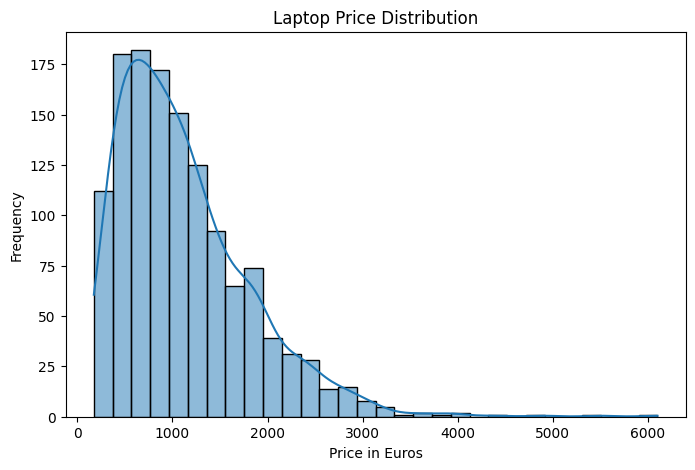

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Price_euros"],
    bins=30,
    kde=True)

plt.title("Laptop Price Distribution")

plt.xlabel("Price in Euros")

plt.ylabel("Frequency")

plt.show()

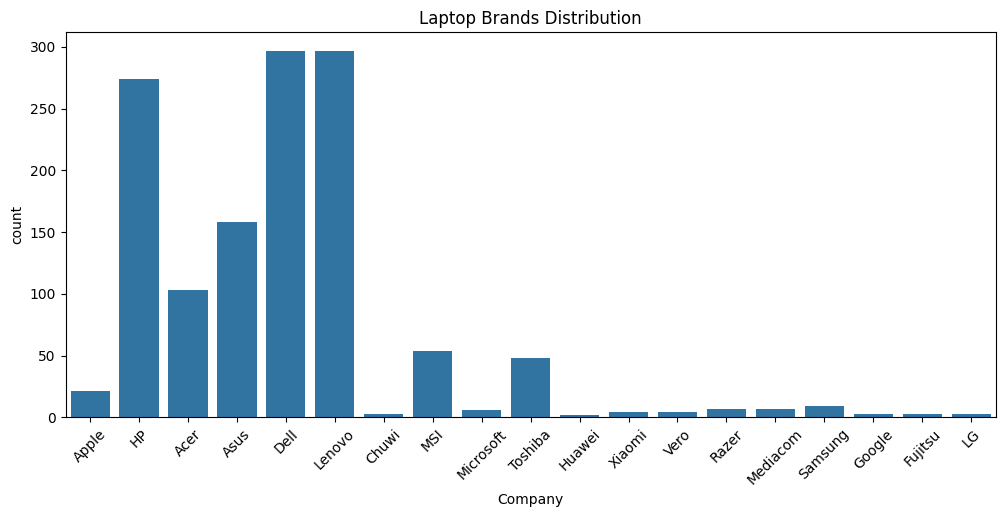

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    x=df["Company"]
)

plt.xticks(rotation=45)

plt.title("Laptop Brands Distribution")

plt.show()

In [ ]:
df["Ram"] = df["Ram"].str.replace("GB", "")
df["Ram"] = df["Ram"].astype("int")

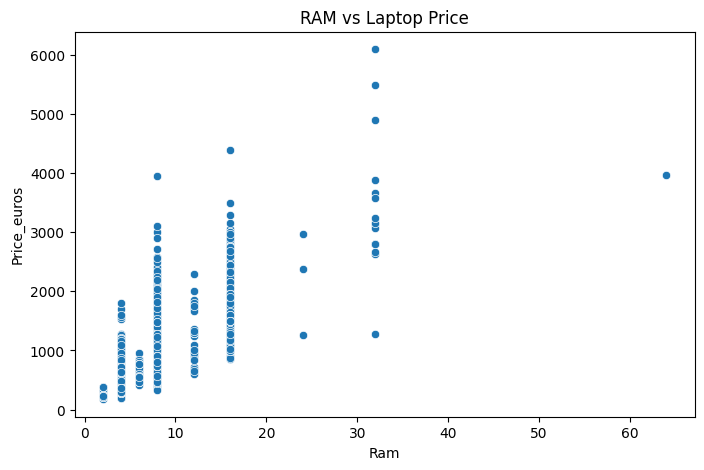

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Ram"],
    y=df["Price_euros"]
)

plt.title("RAM vs Laptop Price")

plt.show()

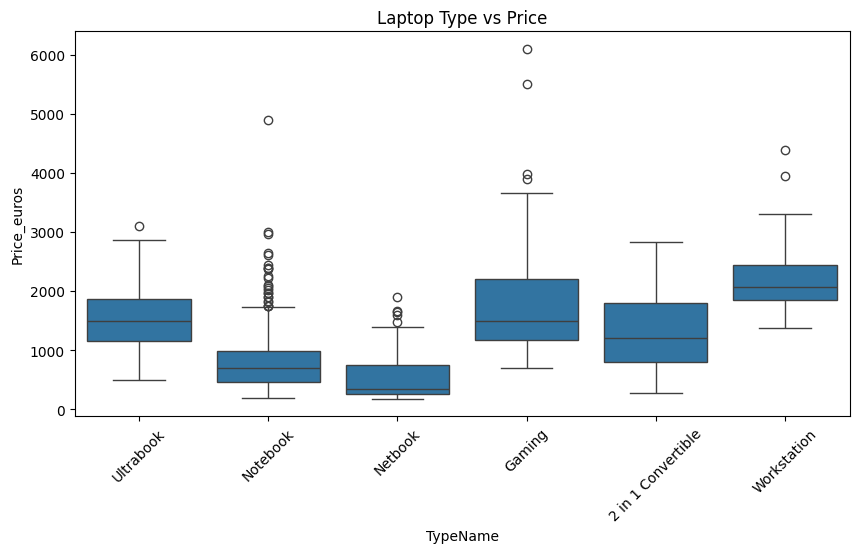

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["TypeName"],
    y=df["Price_euros"])

plt.xticks(rotation=45)

plt.title("Laptop Type vs Price")

plt.show()

In [ ]:
df["Weight"] = df["Weight"].str.replace("kg", "")
df["Weight"] = df["Weight"].astype("float")

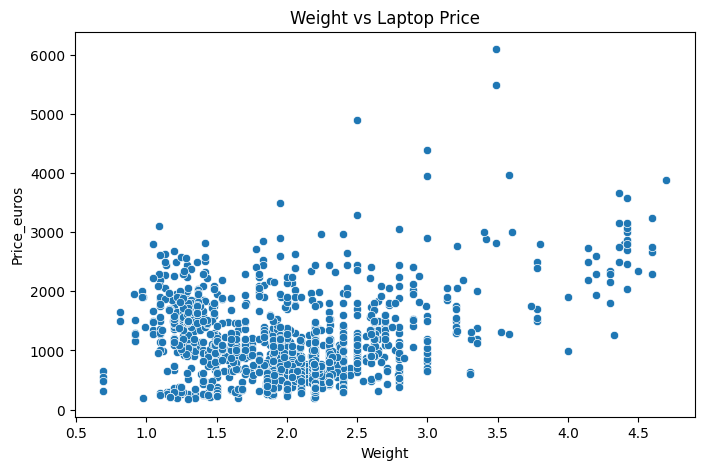

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Weight"],
    y=df["Price_euros"])

plt.title("Weight vs Laptop Price")

plt.show()

#### Feature Engineering

In [ ]:
df["Touchscreen"] = df["ScreenResolution"].apply(
    lambda x: 1 if "Touchscreen" in x else 0)

In [ ]:
df["IPS"] = df["ScreenResolution"].apply(
    lambda x: 1 if "IPS" in x else 0)

In [ ]:
df[["Touchscreen", "IPS"]].head()

,Touchscreen,IPS
0,0,1
1,0,0
2,0,0
3,0,1
4,0,1


In [ ]:
df.select_dtypes(include="object").columns

Index(['Company', 'Product', 'TypeName', 'ScreenResolution', 'Cpu', 'Memory',
       'Gpu', 'OpSys'],
      dtype='object')

In [ ]:
df.dtypes

,0
laptop_ID,int64
Company,object
Product,object
TypeName,object
Inches,float64
ScreenResolution,object
Cpu,object
Ram,int64
Memory,object
Gpu,object


In [ ]:
df["Ram"].dtype

dtype('int64')

In [ ]:
df["Weight"].head()

,Weight
0,1.37
1,1.34
2,1.86
3,1.83
4,1.37


In [ ]:
# Memory'den SSD ve HDD bilgisi çıkarma

df["SSD"] = df["Memory"].apply(lambda x: 1 if "SSD" in x else 0)
df["HDD"] = df["Memory"].apply(lambda x: 1 if "HDD" in x else 0)

In [ ]:
model_df = df[
    [
        "Company",
        "TypeName",
        "Inches",
        "Ram",
        "Weight",
        "OpSys",
        "Touchscreen",
        "IPS",
        "SSD",
        "HDD",
        "Price_euros"]].copy()

In [ ]:
model_df = pd.get_dummies(
    model_df,
    columns=["Company", "TypeName", "OpSys"],
    drop_first=True)

In [ ]:
model_df.head()
model_df.dtypes

,0
Inches,float64
Ram,int64
Weight,float64
Touchscreen,int64
IPS,int64
SSD,int64
HDD,int64
Price_euros,float64
Company_Apple,bool
Company_Asus,bool


In [ ]:
model_df = model_df.astype(int)

In [ ]:
bool_cols = model_df.select_dtypes(include="bool").columns

model_df[bool_cols] = model_df[bool_cols].astype(int)

In [ ]:
model_df.dtypes

,0
Inches,int64
Ram,int64
Weight,int64
Touchscreen,int64
IPS,int64
SSD,int64
HDD,int64
Price_euros,int64
Company_Apple,int64
Company_Asus,int64


In [ ]:
X = model_df.drop("Price_euros", axis=1)
y = model_df["Price_euros"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42 )}

results = []

for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2 })

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,275.568615,391.301713,0.698536
1,Decision Tree,284.610058,470.519367,0.564121
2,Random Forest,253.961670,399.973698,0.685026
3,Gradient Boosting,239.934865,362.176872,0.741743
4,XGBoost,240.643356,399.810072,0.685284


In [ ]:
df["Cpu Brand"] = df["Cpu"].apply(
    lambda x: x.split()[0])

df["Cpu Brand"].value_counts()

,count
Cpu Brand,
Intel,1240
AMD,62
Samsung,1


In [ ]:
df["Gpu Brand"] = df["Gpu"].apply(
    lambda x: x.split()[0])

df["Gpu Brand"].value_counts()

,count
Gpu Brand,
Intel,722
Nvidia,400
AMD,180
ARM,1


In [ ]:
df["FullHD"] = df["ScreenResolution"].apply(
    lambda x: 1 if "1920x1080" in x else 0)

In [ ]:
df["4K"] = df["ScreenResolution"].apply(
    lambda x: 1 if "3840x2160" in x else 0)

In [ ]:
df["SSD_Size"] = df["Memory"].str.extract(r'(\d+)GB SSD')

df["SSD_Size"] = df["SSD_Size"].fillna(0)

df["SSD_Size"] = df["SSD_Size"].astype(int)

In [ ]:
df["HDD_Size"] = df["Memory"].str.extract(r'(\d+)GB HDD')

df["HDD_Size"] = df["HDD_Size"].fillna(0)

df["HDD_Size"] = df["HDD_Size"].astype(int)

In [ ]:
model_df = df[
    [
        "Company",
        "TypeName",
        "Cpu Brand",
        "Gpu Brand",
        "OpSys",
        "Inches",
        "Ram",
        "Weight",
        "Touchscreen",
        "IPS",
        "FullHD",
        "4K",
        "SSD_Size",
        "HDD_Size",
        "Price_euros"]].copy()

In [ ]:
model_df = pd.get_dummies(
    model_df,
    columns=[
        "Company",
        "TypeName",
        "Cpu Brand",
        "Gpu Brand",
        "OpSys"    ],
    drop_first=True)

In [ ]:
bool_cols = model_df.select_dtypes(include="bool").columns

model_df[bool_cols] = model_df[bool_cols].astype(int)

In [ ]:
X = model_df.drop("Price_euros", axis=1)

y = model_df["Price_euros"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

import numpy as np

print("MAE:", mean_absolute_error(y_test, xgb_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

print("R2 Score:", r2_score(y_test, xgb_pred))

MAE: 187.27169265220905
RMSE: 324.8565984978364
R2 Score: 0.7922301662904062


## Model İyileştirme Süreci

İlk regresyon modelleri orta seviyede tahmin performansı göstermiştir.

Model performansını artırmak amacıyla ek feature engineering işlemleri uygulanmıştır.

Uygulanan geliştirmeler:
- İşlemci markası çıkarımı
- Ekran kartı markası çıkarımı
- Full HD ve 4K ekran özellikleri
- SSD ve HDD boyutlarının ayrıştırılması

Feature engineering ve XGBoost hiperparametre optimizasyonu sonrasında model performansı önemli ölçüde artmış ve yaklaşık 0.79 R2 skoruna ulaşılmıştır.

